# OSM transmission update: before/after check

Compares the `validation_dispatch_zambia_2023` (pre-OSM-update) and `validation_dispatch_2023_osm` (post-OSM-update) scenarios:

1. Network map, transmission capacity (`s_nom`) and number of circuits per line
2. Hydro capacity factor statistics (reservoir/dam storage and run-of-river)
3. Time series of hydro generation

**Note on clustering:** the two scenarios were clustered to 10 nodes independently, so cluster bus labels (`ZM0 0`, `ZM0 1`, ...) do **not** refer to the same physical substations across scenarios, the clustering algorithm re-partitions the network in response to topology changes. Where this notebook compares clustered-network quantities (capacity factors, dispatch time series), it matches units by installed capacity (`p_nom`), not by label. The network map in section 1 sidesteps this entirely by using the un-clustered `base.nc` network, matched by physical bus coordinates.

## Setup

In [1]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs

pd.set_option("display.width", 160)

PRE = "validation_dispatch_zambia_2023"
POST = "validation_dispatch_2023_osm"
LABELS = {PRE: "Pre-OSM Update", POST: "Post-OSM Update"}
COLORS = {PRE: "#1b7837", POST: "#762a83"}

# un-clustered, fully-electrified networks (real per-line circuits/s_nom) -- for the map
base_nets = {
    PRE: pypsa.Network(f"../networks/{PRE}/base.nc"),
    POST: pypsa.Network(f"../networks/{POST}/base.nc"),
}

# solved, clustered (10-node) dispatch networks -- for capacity factors and time series
solved_nets = {
    PRE: pypsa.Network(f"../results/{PRE}/networks/elec_s_10_ec_lv1.0_Co2L-3h.nc"),
    POST: pypsa.Network(f"../results/{POST}/networks/elec_s_10_ec_lv1.0_Co2L-3h.nc"),
}

DT_H = 3.0  # snapshot resolution (Co2L-3h)

ERROR 1: PROJ: proj_create_from_database: Open of /home/mwiche/anaconda3/envs/pypsa-earth/share/proj failed


INFO:pypsa.io:Imported network base.nc has buses, lines, line_types, transformers


INFO:pypsa.io:Imported network base.nc has buses, lines, line_types, transformers


INFO:pypsa.io:Imported network elec_s_10_ec_lv1.0_Co2L-3h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units


INFO:pypsa.io:Imported network elec_s_10_ec_lv1.0_Co2L-3h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units


## 1) Network map: transmission capacity and circuits per line

Uses the un-clustered `base.nc` network for each scenario (one row per real OSM-derived line), matched by physical bus coordinates rather than bus label, cluster/base-network bus labels are not stable identifiers across independently-built networks.

/home/mwiche/anaconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


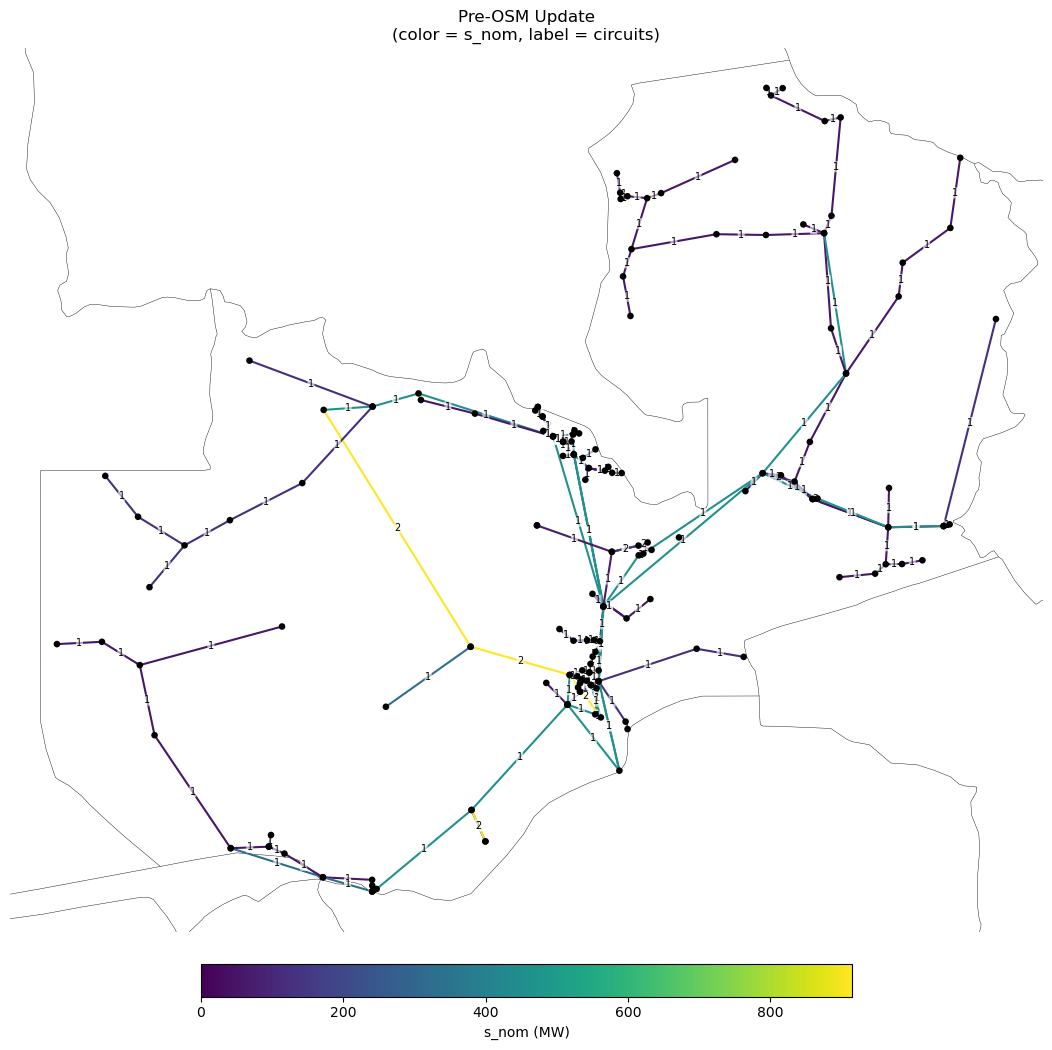

/home/mwiche/anaconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


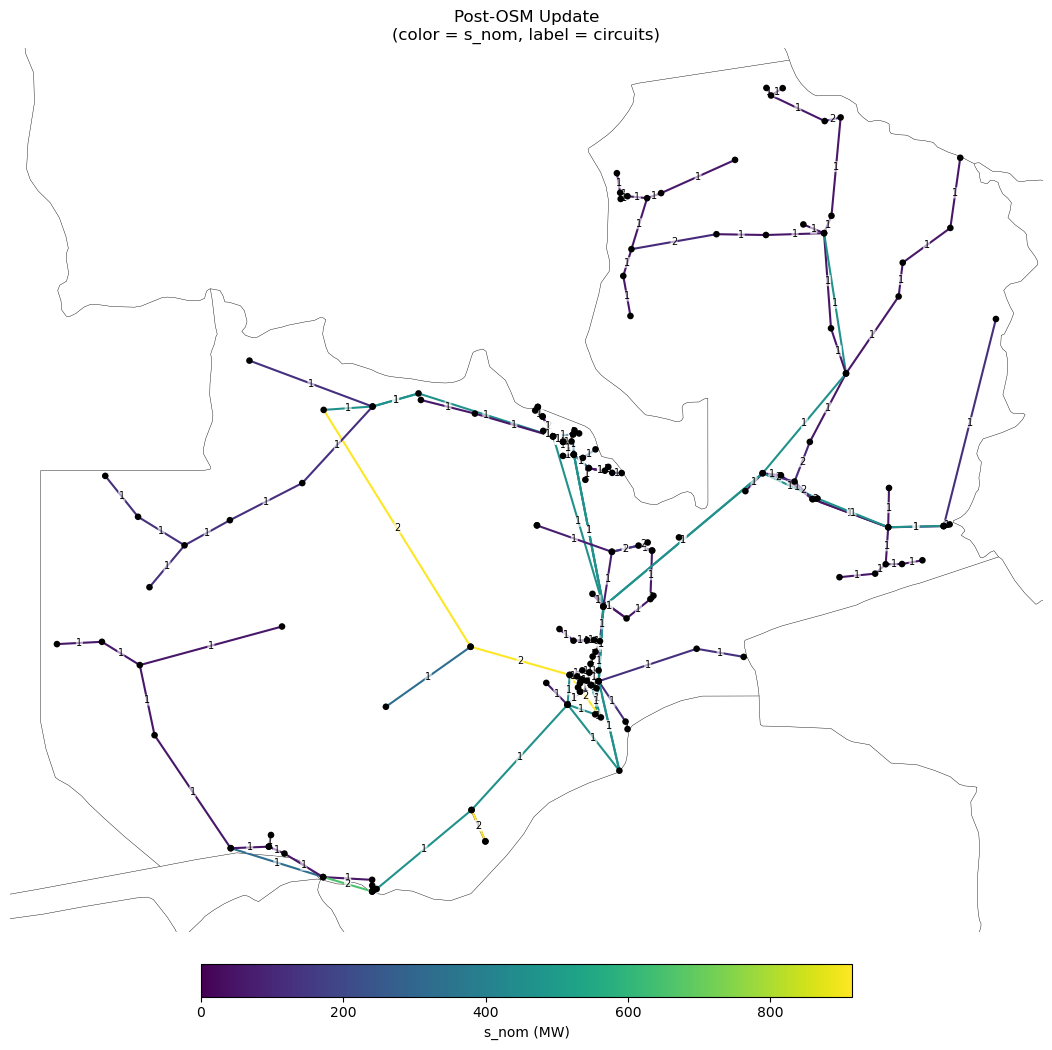


=== Pre-OSM Update ===
num_parallel
1.0    193
2.0      9
Name: count, dtype: int64
total s_nom: 37071 MW  |  total length: 12175 km

=== Post-OSM Update ===
num_parallel
1.0    190
2.0     14
Name: count, dtype: int64
total s_nom: 37721 MW  |  total length: 12353 km


In [2]:
cmap = plt.get_cmap("viridis")
vmax = max(base_nets[PRE].lines["s_nom"].max(), base_nets[POST].lines["s_nom"].max())
norm = mpl.colors.Normalize(vmin=0, vmax=vmax)

for key in [PRE, POST]:
    n = base_nets[key]

    fig, ax = plt.subplots(
        figsize=(14, 14), subplot_kw={"projection": ccrs.PlateCarree()}
    )
    line_colors = n.lines["s_nom"].map(lambda v: cmap(norm(v)))
    n.plot(
        ax=ax,
        line_widths=1.5,
        line_colors=line_colors,
        bus_sizes=0.0015,
        bus_colors="black",
        title=f"{LABELS[key]}\n(color = s_nom, label = circuits)",
    )
    for _, row in n.lines.iterrows():
        x0, y0 = n.buses.loc[row.bus0, ["x", "y"]]
        x1, y1 = n.buses.loc[row.bus1, ["x", "y"]]
        mx, my = (x0 + x1) / 2, (y0 + y1) / 2
        circuits = int(round(row.num_parallel))
        ax.text(
            mx,
            my,
            str(circuits),
            transform=ccrs.PlateCarree(),
            fontsize=7,
            ha="center",
            va="center",
            color="black",
            bbox=dict(boxstyle="round,pad=0.05", fc="white", ec="none", alpha=0.6),
        )

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, shrink=0.6, orientation="horizontal", pad=0.03)
    cbar.set_label("s_nom (MW)")
    plt.show()

for key in [PRE, POST]:
    n = base_nets[key]
    print(f"\n=== {LABELS[key]} ===")
    print(n.lines["num_parallel"].round().value_counts().sort_index())
    print(
        f"total s_nom: {n.lines['s_nom'].sum():.0f} MW  |  total length: {n.lines['length'].sum():.0f} km"
    )

## 2) Hydro capacity factor statistics

Covers both hydro components separately: `StorageUnit` carrier `hydro` (reservoir/dam, dispatchable with inflow + storage) and `Generator` carrier `ror` (run-of-river, essentially must-run on inflow). Units are matched across scenarios by `p_nom` where possible, since cluster bus labels are not stable across the two networks (see intro note).

In [3]:
annual_rows = []
for key in [PRE, POST]:
    n = solved_nets[key]
    label = LABELS[key]

    su = n.storage_units[n.storage_units.carrier == "hydro"]
    for unit, p_nom in su["p_nom"].items():
        energy = n.storage_units_t.p_dispatch[unit].clip(lower=0).sum() * DT_H
        cf = energy / (p_nom * len(n.snapshots) * DT_H)
        annual_rows.append(("hydro (reservoir)", label, unit, p_nom, energy / 1e3, cf))
    total_p_nom = su["p_nom"].sum()
    total_energy = (
        n.storage_units_t.p_dispatch[su.index].clip(lower=0).sum().sum() * DT_H
    )
    annual_rows.append(
        (
            "hydro (reservoir)",
            label,
            "FLEET TOTAL",
            total_p_nom,
            total_energy / 1e3,
            total_energy / (total_p_nom * len(n.snapshots) * DT_H),
        )
    )

    ror = n.generators[n.generators.carrier == "ror"]
    for unit, p_nom in ror["p_nom"].items():
        energy = n.generators_t.p[unit].clip(lower=0).sum() * DT_H
        cf = energy / (p_nom * len(n.snapshots) * DT_H)
        annual_rows.append(("run-of-river", label, unit, p_nom, energy / 1e3, cf))
    total_p_nom = ror["p_nom"].sum()
    total_energy = n.generators_t.p[ror.index].clip(lower=0).sum().sum() * DT_H
    annual_rows.append(
        (
            "run-of-river",
            label,
            "FLEET TOTAL",
            total_p_nom,
            total_energy / 1e3,
            total_energy / (total_p_nom * len(n.snapshots) * DT_H),
        )
    )

annual_df = pd.DataFrame(
    annual_rows,
    columns=["type", "scenario", "unit", "p_nom_MW", "energy_GWh", "capacity_factor"],
)
annual_df

,type,scenario,unit,p_nom_MW,energy_GWh,capacity_factor
0,hydro (reservoir),Pre-OSM Update,ZM0 0 hydro,27.0,34.537985,0.146026
1,hydro (reservoir),Pre-OSM Update,ZM0 1 hydro,1740.0,1388.476357,0.091093
2,hydro (reservoir),Pre-OSM Update,ZM0 5 hydro,10.0,87.414000,0.997877
3,hydro (reservoir),Pre-OSM Update,ZM0 6 hydro,56.0,225.726665,0.460141
4,hydro (reservoir),Pre-OSM Update,ZM0 7 hydro,1080.0,9422.208086,0.995921
5,hydro (reservoir),Pre-OSM Update,ZM0 8 hydro,120.0,1051.200000,1.000000
6,hydro (reservoir),Pre-OSM Update,FLEET TOTAL,3033.0,12209.563094,0.459540
7,run-of-river,Pre-OSM Update,ZM0 4 ror,108.0,932.450438,0.985594
8,run-of-river,Pre-OSM Update,ZM0 5 ror,30.8,124.916718,0.462984
9,run-of-river,Pre-OSM Update,FLEET TOTAL,138.8,1057.367156,0.869625


In [4]:
# monthly capacity factor, fleet-aggregate
monthly_rows = []
for key in [PRE, POST]:
    n = solved_nets[key]
    label = LABELS[key]
    su = n.storage_units[n.storage_units.carrier == "hydro"]
    ror = n.generators[n.generators.carrier == "ror"]
    hydro_p = n.storage_units_t.p_dispatch[su.index].clip(lower=0).sum(axis=1)
    ror_p = n.generators_t.p[ror.index].clip(lower=0).sum(axis=1)
    hydro_p_nom = su["p_nom"].sum()
    ror_p_nom = ror["p_nom"].sum()
    for month, grp in hydro_p.groupby(hydro_p.index.month):
        hours = len(grp) * DT_H
        cf = (grp.sum() * DT_H) / (hydro_p_nom * hours)
        monthly_rows.append(("hydro (reservoir)", label, month, cf))
    for month, grp in ror_p.groupby(ror_p.index.month):
        hours = len(grp) * DT_H
        cf = (grp.sum() * DT_H) / (ror_p_nom * hours)
        monthly_rows.append(("run-of-river", label, month, cf))

monthly_df = pd.DataFrame(
    monthly_rows, columns=["type", "scenario", "month", "capacity_factor"]
)
pivot = monthly_df.pivot_table(
    index="month", columns=["type", "scenario"], values="capacity_factor"
)
pivot

type     hydro (reservoir)                   run-of-river               
scenario   Post-OSM Update Pre-OSM Update Post-OSM Update Pre-OSM Update
month                                                                   
1                 0.493031       0.450667        0.000000       0.911519
2                 0.511086       0.471269        0.004545       0.913318
3                 0.503574       0.463426        0.000414       0.908773
4                 0.491058       0.447520        0.000831       0.979374
5                 0.490852       0.453867        0.000932       0.909263
6                 0.483276       0.445322        0.000718       0.860146
7                 0.478361       0.439180        0.000000       0.853808
8                 0.481922       0.440202        0.000874       0.850748
9                 0.513102       0.471706        0.007151       0.847992
10                0.521400       0.480987        0.008983       0.840029
11                0.519220       0.479578        0.007846       0.791381
12                0.506517       0.472089        0.002503       0.773396

## 3) Time series of hydro generation

Weekly-mean dispatch for the reservoir/dam fleet and the run-of-river fleet, plus load shedding for context. Reservoir inflow/spill are deliberately excluded here, GloFAS-derived river discharge is roughly two orders of magnitude larger than installed turbine capacity (~98.7% is spilled in both scenarios), so it swamps the y-axis and isn't diagnostic for this comparison. If you want to inspect it anyway, `n.storage_units_t.inflow` / `.spill` are there per storage unit.

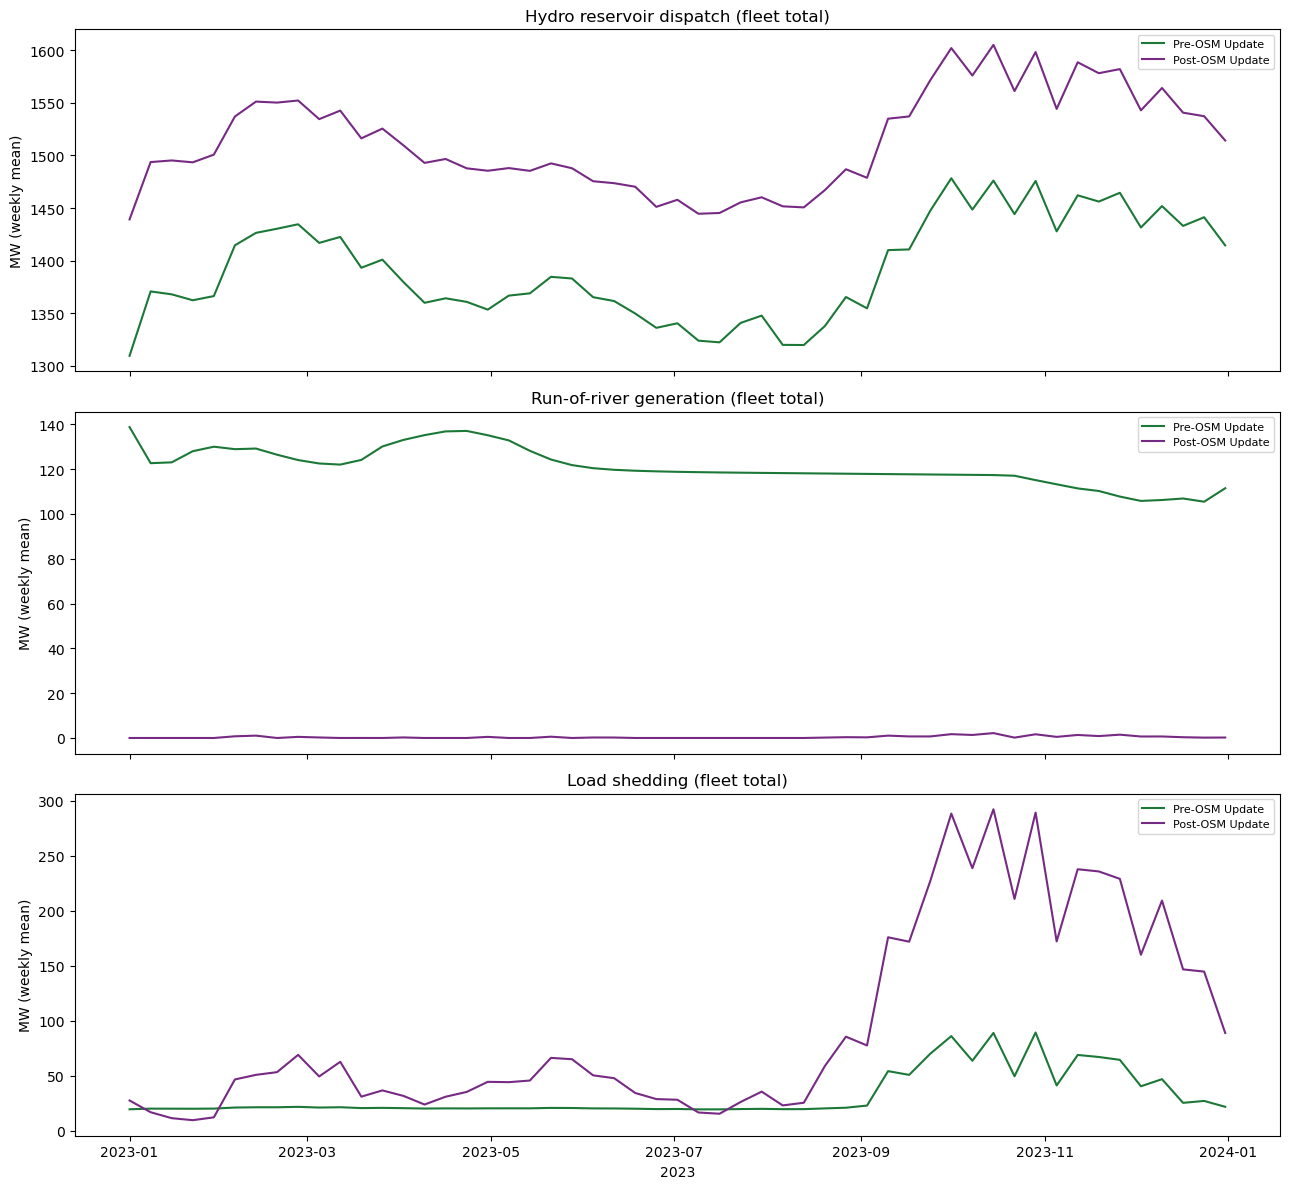

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True)

for key in [PRE, POST]:
    n = solved_nets[key]
    label = LABELS[key]
    su = n.storage_units[n.storage_units.carrier == "hydro"]
    ror = n.generators[n.generators.carrier == "ror"]
    load_shed_gens = n.generators.index[n.generators.carrier == "load shedding"]

    hydro_dispatch = n.storage_units_t.p_dispatch[su.index].clip(lower=0).sum(axis=1)
    ror_gen = n.generators_t.p[ror.index].clip(lower=0).sum(axis=1)
    load_shed = n.generators_t.p[load_shed_gens].sum(axis=1)

    axes[0].plot(hydro_dispatch.resample("W").mean(), label=label, color=COLORS[key])
    axes[1].plot(ror_gen.resample("W").mean(), label=label, color=COLORS[key])
    axes[2].plot(load_shed.resample("W").mean(), label=label, color=COLORS[key])

axes[0].set_ylabel("MW (weekly mean)")
axes[0].set_title("Hydro reservoir dispatch (fleet total)")
axes[0].legend(fontsize=8)

axes[1].set_ylabel("MW (weekly mean)")
axes[1].set_title("Run-of-river generation (fleet total)")
axes[1].legend(fontsize=8)

axes[2].set_ylabel("MW (weekly mean)")
axes[2].set_title("Load shedding (fleet total)")
axes[2].legend(fontsize=8)
axes[2].set_xlabel("2023")

plt.tight_layout()
plt.show()